<a href="https://colab.research.google.com/github/v2rinku/forqiskitalgo/blob/main/vqe_etc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Coding with Qiskit

# Hello World!

=
The application first entangled two qubits which were initially in the state $\vert00\rangle$. Then, we noted the results by running the application on a simulator as well as real quantum hardware at IBM.

This Jupyter notebook shows the code that was used in the video, as well as updates in the latest version of Qiskit.

**Link to Episode 3:** https://www.youtube.com/watch?v=RrUTwq5jKM4

In [1]:
!pip install qiskit qiskit_aer matplotlib pylatexenc qiskit_ibm_runtime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 71.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 381.8/381.8 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 7.9 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=db9df4bb55563970d9fc6bacb3dd72b891f6a2a629888a9cf9d631ab91cff4dc
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178b

In [22]:
# START OF VQE
# https://quantum.cloud.ibm.com/learning/en/courses/quantum-diagonalization-algorithms/vqe


In [3]:
# General imports
import numpy as np

# SciPy minimizer routine
from scipy.optimize import minimize

# Plotting functions
import matplotlib.pyplot as plt

In [4]:
from qiskit.quantum_info import SparsePauliOp
import numpy as np

hamiltonian = SparsePauliOp.from_list(
    [("YZ", 0.3980), ("ZI", -0.3980), ("ZZ", -0.0113), ("XX", 0.1810)]
)

A = np.array(hamiltonian)
eigenvalues, eigenvectors = np.linalg.eigh(A)
print("The ground state energy is ", min(eigenvalues))

The ground state energy is  -0.702930394459531


This circuit has  4 parameters


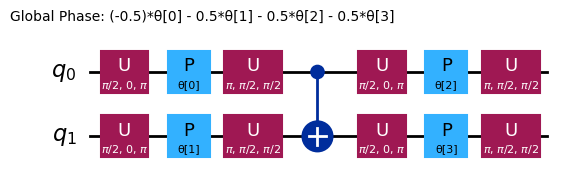

In [5]:
# Pre-defined ansatz circuit and operator class for Hamiltonian
from qiskit.circuit.library import efficient_su2

# Note that it is more common to place initial 'h' gates outside the ansatz. Here we specifically wanted this layer structure.
ansatz = efficient_su2(
    hamiltonian.num_qubits, su2_gates=["h", "rz", "y"], entanglement="circular", reps=1
)

num_params = ansatz.num_parameters
print("This circuit has ", num_params, "parameters")

ansatz.decompose().draw("mpl", style="iqp")

In [10]:
# runtime imports
#from qiskit_ibm_runtime import QiskitRuntimeService, Session
#from qiskit_ibm_runtime import EstimatorV2 as Estimator

# To run on hardware, select the backend with the fewest number of jobs in the queue
#service = QiskitRuntimeService()
#backend = service.least_busy(operational=True, simulator=False)

#print(backend)

In [9]:
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import EstimatorV2 as AerEstimator

# Use AerSimulator as a local dummy backend
backend = AerSimulator()

# If you need an Estimator, use the Aer version
estimator = AerEstimator()

print("Using AerSimulator as the backend for transpilation:", backend.name())
print("Using AerEstimator for local computations:", estimator)

TypeError: 'str' object is not callable

In [12]:
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import EstimatorV2 as AerEstimator

# Use AerSimulator as a local dummy backend
backend = AerSimulator()

# If you need an Estimator, use the Aer version
estimator = AerEstimator()

print( backend)
print("Using AerEstimator for local computations:", estimator)

AerSimulator('aer_simulator')
Using AerEstimator for local computations: <qiskit_aer.primitives.estimator_v2.EstimatorV2 object at 0x7bd517635580>


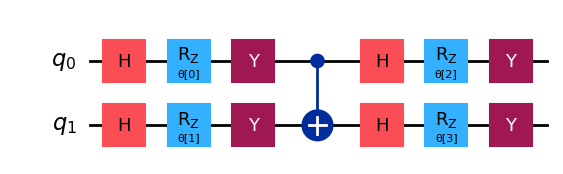

In [13]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

ansatz_isa = pm.run(ansatz)

ansatz_isa.draw(output="mpl", idle_wires=False, style="iqp")

In [14]:
def cost_func(params, ansatz, hamiltonian, estimator):
    """Return estimate of energy from estimator

    Parameters:
        params (ndarray): Array of ansatz parameters
        ansatz (QuantumCircuit): Parameterized ansatz circuit
        hamiltonian (SparsePauliOp): Operator representation of Hamiltonian
        estimator (EstimatorV2): Estimator primitive instance
        cost_history_dict: Dictionary for storing intermediate results

    Returns:
        float: Energy estimate
    """
    pub = (ansatz, [hamiltonian], [params])
    result = estimator.run(pubs=[pub]).result()
    energy = result[0].data.evs[0]

    cost_history_dict["iters"] += 1
    cost_history_dict["prev_vector"] = params
    cost_history_dict["cost_history"].append(energy)
    print(f"Iters. done: {cost_history_dict['iters']} [Current cost: {energy}]")

    return energy


cost_history_dict = {
    "prev_vector": None,
    "iters": 0,
    "cost_history": [],
}

In [15]:
x0 = 2 * np.pi * np.random.random(num_params)

In [17]:
hamiltonian_isa = hamiltonian.apply_layout(layout=ansatz_isa.layout)

In [18]:
# This required 13 min, 20 s QPU time on an Eagle processor, 28 min total time.
with Session(backend=backend) as session:
    estimator = Estimator(mode=session)
    estimator.options.default_shots = 10000

    res = minimize(
        cost_func,
        x0,
        args=(ansatz_isa, hamiltonian_isa, estimator),
        method="cobyla",
        options={"maxiter": 50},
    )

Iters. done: 1 [Current cost: 0.32569900000000007]
Iters. done: 2 [Current cost: 0.13653764000000002]
Iters. done: 3 [Current cost: -0.35750625999999996]
Iters. done: 4 [Current cost: -0.29963056]
Iters. done: 5 [Current cost: -0.15885044]
Iters. done: 6 [Current cost: -0.5963975800000001]
Iters. done: 7 [Current cost: -0.30643016]
Iters. done: 8 [Current cost: -0.40187178]
Iters. done: 9 [Current cost: -0.5465773800000001]
Iters. done: 10 [Current cost: -0.58262042]
Iters. done: 11 [Current cost: -0.6055898]
Iters. done: 12 [Current cost: -0.62628208]
Iters. done: 13 [Current cost: -0.6311577]
Iters. done: 14 [Current cost: -0.6294520000000001]
Iters. done: 15 [Current cost: -0.626846]
Iters. done: 16 [Current cost: -0.64406802]
Iters. done: 17 [Current cost: -0.66207936]
Iters. done: 18 [Current cost: -0.65562562]
Iters. done: 19 [Current cost: -0.68371512]
Iters. done: 20 [Current cost: -0.6845869200000001]
Iters. done: 21 [Current cost: -0.6870517]
Iters. done: 22 [Current cost: -0

In [19]:
res

 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: -0.7066077000000001
       x: [ 4.553e+00  5.278e+00  2.906e+00  4.655e+00]
    nfev: 46
   maxcv: 0.0

In [20]:
cost_history_dict

{'prev_vector': array([4.55305927, 5.27761618, 2.90638274, 4.65453329]),
 'iters': 46,
 'cost_history': [np.float64(0.32569900000000007),
  np.float64(0.13653764000000002),
  np.float64(-0.35750625999999996),
  np.float64(-0.29963056),
  np.float64(-0.15885044),
  np.float64(-0.5963975800000001),
  np.float64(-0.30643016),
  np.float64(-0.40187178),
  np.float64(-0.5465773800000001),
  np.float64(-0.58262042),
  np.float64(-0.6055898),
  np.float64(-0.62628208),
  np.float64(-0.6311577),
  np.float64(-0.6294520000000001),
  np.float64(-0.626846),
  np.float64(-0.64406802),
  np.float64(-0.66207936),
  np.float64(-0.65562562),
  np.float64(-0.68371512),
  np.float64(-0.6845869200000001),
  np.float64(-0.6870517),
  np.float64(-0.70125166),
  np.float64(-0.69118556),
  np.float64(-0.6969069800000001),
  np.float64(-0.69981274),
  np.float64(-0.6910874),
  np.float64(-0.69425376),
  np.float64(-0.69258918),
  np.float64(-0.7066077000000001),
  np.float64(-0.69323716),
  np.float64(-0.6970

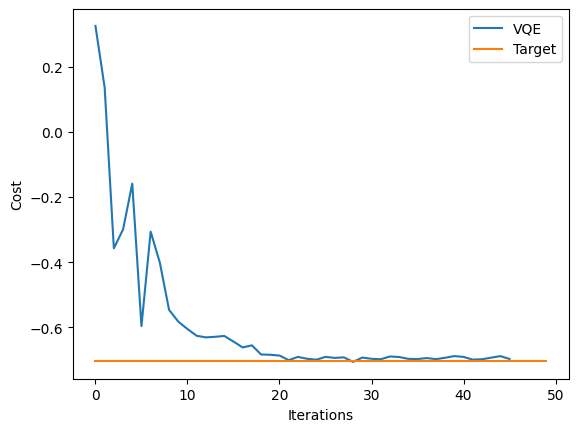

In [21]:
fig, ax = plt.subplots()
x = np.linspace(0, 10, 50)

# Define the constant function
constant = -0.7029
y_constant = np.full_like(x, constant)
ax.plot(
    range(cost_history_dict["iters"]), cost_history_dict["cost_history"], label="VQE"
)
ax.set_xlabel("Iterations")
ax.set_ylabel("Cost")
ax.plot(y_constant, label="Target")
plt.legend()
plt.draw()

In [23]:
# START OF Krylov
# https://quantum.cloud.ibm.com/learning/en/courses/quantum-diagonalization-algorithms/krylov

In [24]:
# One might use linalg.eigh here, but later matrices may not be Hermitian. So we use linalg.eig in this lesson.

import numpy as np

A = np.array([[4, -1, 0], [-1, 4, -1], [0, -1, 4]])
eigenvalues, eigenvectors = np.linalg.eig(A)
print("The eigenvalues are ", eigenvalues)
print("The eigenvectors are ", eigenvectors)

The eigenvalues are  [2.58578644 4.         5.41421356]
The eigenvectors are  [[ 5.00000000e-01 -7.07106781e-01  5.00000000e-01]
 [ 7.07106781e-01  1.37464400e-16 -7.07106781e-01]
 [ 5.00000000e-01  7.07106781e-01  5.00000000e-01]]


In [25]:
# vknown is some established vector in our subspace. vnext is one we wish to add, which must be orthogonal to vknown.


def orthog_pair(vknown, vnext):
    vknown = vknown / np.sqrt(vknown.T @ vknown)
    diffvec = vknown.T @ vnext * vknown
    vnext = vnext - diffvec
    return vnext


# v is the candidate vector to be added to our subspace. s is the existing subspace.


def orthoset(v, s):
    v = v / np.sqrt(v.T @ v)
    temp = v
    for i in range(len(s)):
        temp = orthog_pair(s[i], temp)
    v = temp / np.sqrt(temp.T @ temp)
    return v

In [26]:
# Necessary imports and definitions to track time in microseconds
import time


def time_mus():
    return int(time.time() * 1000000)


# This function constructs a Krylov subspace that spans the whole space of the original matrix.
#     Input:
#       v0          : initial vector
#       matrix      : original matrix to be diagonalized
#     Output:
#       ks          : Krylov vectors
#       Hs          : projected Hamiltonians
#       eigs        : eigenvalues
#       k_tot_times : time required for the operation


def krylov_full_build(v0, matrix):
    t0 = time_mus()
    b = v0 / np.sqrt(v0 @ v0.T)
    A = matrix
    ks = []
    ks.append(b)
    Hs = []
    eigs = []
    Hs.append(b.T @ A @ b)
    eigs.append(np.array([b.T @ A @ b]))
    k_tot_times = []

    for j in range(len(A) - 1):
        vec = A @ ks[j].T
        ortho = orthoset(vec, ks)
        ks.append(ortho)
        ksarray = np.array(ks)
        Hs.append(ksarray @ A @ ksarray.T)
        eigs.append(np.linalg.eig(Hs[j + 1]).eigenvalues)
        k_tot_times.append(time_mus() - t0)

    # Return the Krylov vectors, the projected Hamiltonians, the eigenvalues, and the total time required.
    return (ks, Hs, eigs, k_tot_times)

In [27]:
# Define our small test matrix
test_matrix = np.array(
    [
        [4, -1, 0, 1, 0],
        [-1, 4, -1, 2, 1],
        [0, -1, 4, 3, 3],
        [1, 2, 3, 4, 0],
        [0, 1, 3, 0, 4],
    ]
)

# Give the test matrix and an initial guess as arguments in the function defined above. Calculate outputs.
test_ks, test_Hs, test_eigs, text_k_tot_times = krylov_full_build(
    np.array([0.5, 0.5, 0, 0.5, 0.5]), test_matrix
)

In [ ]:
print(np.linalg.eig(test_matrix).eigenvalues)
print(test_eigs[len(test_matrix) - 1])
def errors(matrix, krylov_eigs):
    targ_min = min(np.linalg.eig(matrix).eigenvalues)
    err = []
    for i in range(len(matrix)):
        err.append(min(krylov_eigs[i]) - targ_min)
    return err

In [28]:
import matplotlib.pyplot as plt

krylov_error = errors(test_matrix, test_eigs)

plt.plot(krylov_error)
plt.axhline(y=0, color="red", linestyle="--")  # Add dashed red line at y=0
plt.xlabel("Order of Krylov subspace")  # Add x-axis label
plt.ylabel("Error in minimum eigenvalue")  # Add y-axis label
plt.show()

NameError: name 'errors' is not defined

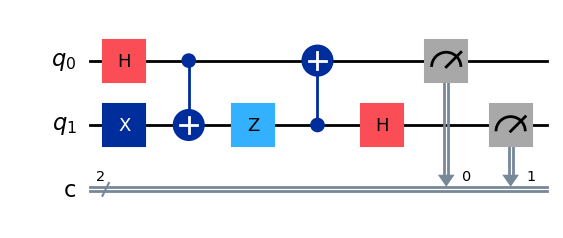

In [ ]:
from qiskit import QuantumCircuit
# Create a quantum circuit with 2 qubits
qc = QuantumCircuit(2,2)
qc.x(1)   # qubit 1 -> |1>, qubit 0 stays |0>

qc.h(0)
qc.cx(0, 1)
qc.z(1)
qc.cx(1, 0)
qc.h(1)
qc.measure([0, 1], [0, 1])
qc.draw('mpl')


In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit_aer.primitives import SamplerV2
from qiskit import QuantumCircuit, QuantumRegister, transpile
from qiskit.quantum_info import Statevector

qc.save_statevector()

# build simulator and transpile
sim = AerSimulator(method='statevector')
qc_compiled = transpile(qc, sim)

# run and get result
job = sim.run(qc_compiled)
result = job.result()
counts = result.get_counts()
print(counts)
# get the experiment's statevector
statevector = result.get_statevector()
sv = Statevector(statevector)
print(statevector)




statevector.draw('latex')


{'11': 1024}
Statevector([0.+0.000000e+00j, 0.+0.000000e+00j, 0.+0.000000e+00j,
             1.-6.123234e-17j],
            dims=(2, 2))


<IPython.core.display.Latex object>

# Building the circuit

We begin by importing Qiskit.

In [ ]:
!pip install qiskit qiskit_aer matplotlib pylatexenc qiskit_ibm_runtime


In [ ]:
from qiskit import *

In the video, we initialized two qubits into a `QuantumRegister` and two classical bits into a `ClassicalRegister` by writing

In [ ]:
qr = QuantumRegister(2)
cr = ClassicalRegister(2)

Then we built a `QuantumCircuit` composed of the two classical and quantum bits by saying

In [ ]:
circuit = QuantumCircuit(qr, cr)

The above three lines of code can be simplified into one line by writing

In [ ]:
circuit = QuantumCircuit(2,2)

where the first argument is the number of quantum bits, and the second argument is the number of classical bits. This is the recommended way of creating circuits.

Once you create your circuit, you can draw it at any point by writing

In [ ]:
circuit.draw()

q_0: 
     
q_1: 
     
c: 2/

For a plot based on `matplotlib`, use instead

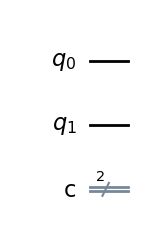

In [ ]:
%matplotlib inline
circuit.draw(output='mpl')

Note that you only need to run the `%matplotlib inline` command once in your notebook.

Next, let's add the gates.

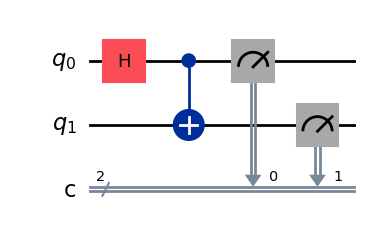

In [ ]:
# the quantum circuit has two qubits. they are indexed as qubits 0 and 1
circuit.h(0)
circuit.cx(0,1) # order is control, target
circuit.measure([0,1], [0,1]) # qubits [0,1] are measured and results are stored in classical bits [0,1] in order
circuit.draw(output='mpl')

# Running on a simulator

We begin by setting the simulator to `qasm_simulator` from the Aer element of Qiskit.

In [ ]:
from qiskit_aer import  Aer, QasmSimulator
backend = QasmSimulator()
qc_compiled = transpile(circuit, backend)


Then, we execute the circuit on the simulator and store the results in a variable called `result`.

In [ ]:
job_sim = backend.run(circuit, shots=100)
result = job_sim.result()
counts = result.get_counts(circuit)
print(counts)

{'11': 49, '00': 51}


At this point, we are ready to plot the results of the simulator execution. To do this, first import the visualization tools from Qiskit using

In [ ]:
from qiskit.visualization import plot_histogram

Then, we plot the results using

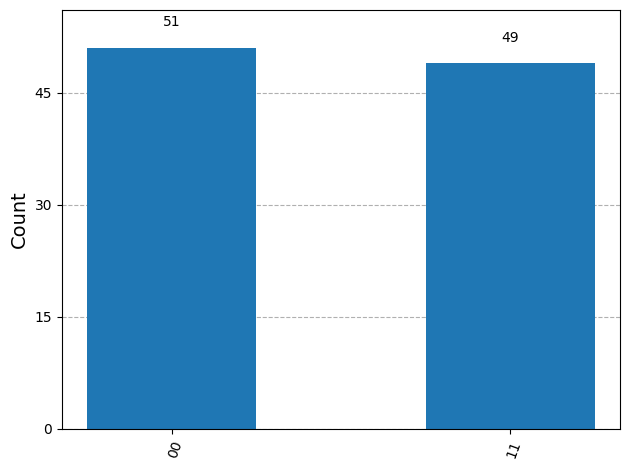

In [ ]:
plot_histogram(result.get_counts(circuit))

# Running on real quantum hardware

In order to run the circuit on real quantum hardware at IBM, we begin by loading our saved IBMQ account using

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService
QiskitRuntimeService.save_account(
    channel="ibm_cloud",
    token="token",
    set_as_default=True,
    overwrite=True

)

service = QiskitRuntimeService("ibm_cloud")
print(service.backends())


qiskit_runtime_service._resolve_cloud_instances:WARNING:2025-07-09 18:39:13,687: Default instance not set. Searching all available instances.
qiskit_runtime_service._resolve_cloud_instances:WARNING:2025-07-09 18:39:14,422: Default instance not set. Searching all available instances.


[]


Once the backend is selected, we are ready to run the circuit just as before using the `execute` function. Before doing so, a useful feature is to run the job watcher that is available in the latest version of Qiskit using

# References

For detailed information about Qiskit, check out the tutorials in the Github repository:

https://github.com/Qiskit/qiskit-iqx-tutorials